In [25]:
from IPython.display import clear_output, display, Markdown, HTML
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
import random
import time

import utils.dataset_generation as generate


In [68]:
### Functions (temporary, move to generate once ready)

## Production functions

def cluster_attributes() -> dict:
    a_stats = {}  # Whale

    b_stats = {  # Babylonin lammas
        'session_start_mu': 13.1685,#13.123,
        'session_start_sigma': 0.1,#0.23
        'session_length_mu': 3600,  # 1 hour in seconds
        'session_length_sigma': 1200  # 20 minutes in seconds
    }

    c_stats = {}  # Grind set

    d_stats = {  # Skin-Veeti
        'session_start_mu': 9.99,#10.684,#13.123,
        'session_start_sigma': 0.1#0.23
    }

    e_stats = {}  # Purchase curious

    f_stats = {}  # Churned

    g_stats = {  # Free to play
        'session_start_mu': 11.3,#11.78,#12.07,#13.123,
        'session_start_sigma': 0.2,#0.23
        'session_length_mu': 1200,  # 20 minutes in seconds
        'session_length_sigma': 500
    }


    cluster_stats = {
        'a': a_stats,
        'b': b_stats,
        'c': c_stats,
        'd': d_stats,
        'e': e_stats,
        'f': f_stats,
        'g': g_stats,
    }

    return cluster_stats


def session_start(initial_timestamp, mu, sigma, max_days=180):
    # Convert initial timestamp to pandas Timestamp
    initial_time = pd.Timestamp(initial_timestamp)

    # Generate lognormal distribution
    seconds_after = np.random.lognormal(mean=mu, sigma=sigma)#, size=num_samples)

    # Limit timescale to max_days
    max_seconds = max_days * 24 * 60 * 60  # Convert days to seconds
    if seconds_after > max_seconds:
        return None

    session_start_time = initial_time + pd.Timedelta(seconds=seconds_after)
    return session_start_time


def session_end(mean, std_dev, start_timestamp=None):
    """
    Generate a timestamp offset from the start using a bounded normal distribution.

    Parameters:
        start_timestamp (str or pd.Timestamp): Starting timestamp in 'YYYY-MM-DD HH:MM:SS' format.
        mean (float): Mean of the normal distribution (in seconds).
        std_dev (float): Standard deviation of the normal distribution (in seconds).

    Returns:
        pd.Timestamp: Generated timestamp.
    """

    # Define bounds (2 standard deviations)
    lower_bound = mean - 2 * std_dev
    upper_bound = mean + 5 * std_dev

    # Generate a valid value within bounds
    while True:
        value = np.random.normal(loc=mean, scale=std_dev)
        if lower_bound <= value <= upper_bound:
            break

    # Rescale the distribution to fit within the bounds
    scaled_value = value

    # Add the offset to the starting timestamp (if given)
    if start_timestamp is not None:
        # Convert start_timestamp to pandas Timestamp
        start_time = pd.Timestamp(start_timestamp)
        generated_timestamp = start_time + pd.Timedelta(seconds=scaled_value)
    else:
        generated_timestamp = None

    return scaled_value, generated_timestamp



## Auxiliary functions

def find_lognormal_params(target_mode, target_range, tolerance=0.01):
    """
    Determine suitable mu and sigma for a lognormal distribution with the given mode and range.

    Parameters:
        target_mode (float): Desired mode of the distribution (in seconds).
        target_range (tuple): Desired range (in seconds) where most values should fall.
        tolerance (float): Allowed deviation from 68% probability within the range.

    Returns:
        tuple: (mu, sigma) for the lognormal distribution.
    """
    # Define range bounds
    lower_bound, upper_bound = target_range

    best_probability = 0

    # Iterate over possible sigma values
    for sigma in np.linspace(0.1, 1.0, 1000):
        # Calculate mu based on the mode equation
        mu = np.log(target_mode) + sigma**2
        
        # Calculate the CDF at the range bounds
        cdf_lower = lognorm.cdf(lower_bound, s=sigma, scale=np.exp(mu))
        cdf_upper = lognorm.cdf(upper_bound, s=sigma, scale=np.exp(mu))
        
        # Check if the cumulative probability within the range meets the tolerance

        new_probability = cdf_upper - cdf_lower

        if new_probability > best_probability:
            best_probability = new_probability

        if (new_probability) >= (1 - tolerance):
            return mu, sigma, new_probability

    raise ValueError(f"Suitable parameters not found within the given tolerance.  Best probability reached: {best_probability}")


def plot_session_start_distribution(initial_timestamp, mu, sigma, num_samples=1000, max_days=180, time_unit='seconds'):
    """
    Plot the distribution of session start times based on a lognormal distribution.

    Parameters:
        initial_timestamp (str): Initial session start time in 'YYYY-MM-DD HH:MM:SS' format.
        mu (float): Mean (log scale) for the lognormal distribution.
        sigma (float): Standard deviation (log scale) for the lognormal distribution.
        num_samples (int): Number of samples to generate for the lognormal distribution.
        max_days (int): Maximum number of days after the initial timestamp to consider.
        time_unit (str): Unit for x-axis ('seconds', 'minutes', 'hours', 'days').

    Returns:
        None: Displays the plot.
    """
    # Time unit conversion factors
    time_factors = {
        'seconds': 1,
        'minutes': 60,
        'hours': 3600,
        'days': 86400
    }

    if time_unit not in time_factors:
        raise ValueError("Invalid time_unit. Choose from 'seconds', 'minutes', 'hours', or 'days'.")

    # Convert initial timestamp to pandas Timestamp
    initial_time = pd.Timestamp(initial_timestamp)

    # Generate lognormal distribution
    seconds_after = np.random.lognormal(mean=mu, sigma=sigma, size=num_samples)

    # Limit timescale to max_days
    max_seconds = max_days * 24 * 60 * 60  # Convert days to seconds
    seconds_after = seconds_after[seconds_after <= max_seconds]

    # Scale seconds_after based on the selected time_unit
    scaled_values = seconds_after / time_factors[time_unit]

    # Create a histogram for visualization
    count, bins, _ = plt.hist(scaled_values, bins=100, density=True, alpha=0.5, color='blue', align='mid')

    # Generate PDF for the lognormal distribution
    x = np.linspace(min(bins), max(bins), 10000)
    pdf = (np.exp(-(np.log(x * time_factors[time_unit]) - mu)**2 / (2 * sigma**2)) /
           (x * time_factors[time_unit] * sigma * np.sqrt(2 * np.pi))) * time_factors[time_unit]
    plt.plot(x, pdf, linewidth=2, color='red', label='Lognormal PDF')

    # Plot settings
    plt.title('Session Start Time Distribution')
    plt.xlabel(f'Time After Initial Session ({time_unit})')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Show plot
    plt.show()

    # Optional: Print the first few session times for inspection
    print("First few session start times:")
    session_start_times = [initial_time + pd.Timedelta(seconds=sec) for sec in seconds_after]
    print(pd.Series(session_start_times).sort_values().head(10))


def plot_session_length_distribution(mu, sigma, num_samples=1000, max_seconds=86400, time_unit='minutes'):
    """
    Plot the distribution of session lengths based on a lognormal distribution.

    Parameters:
        mu (float): Mean (log scale) for the lognormal distribution.
        sigma (float): Standard deviation (log scale) for the lognormal distribution.
        num_samples (int): Number of samples to generate for the lognormal distribution.
        max_seconds (int): Maximum session length to consider (in seconds).
        time_unit (str): Unit for x-axis ('seconds', 'minutes', 'hours', 'days').

    Returns:
        None: Displays the plot.
    """
    # Time unit conversion factors
    time_factors = {
        'seconds': 1,
        'minutes': 60,
        'hours': 3600,
        'days': 86400
    }

    if time_unit not in time_factors:
        raise ValueError("Invalid time_unit. Choose from 'seconds', 'minutes', 'hours', or 'days'.")

    # Generate session lengths using the session_end function
    session_lengths = []
    for _ in range(num_samples):
        scaled_value, _ = session_end(mean=mu, std_dev=sigma)
        if scaled_value <= max_seconds:  # Ensure lengths are within max_seconds
            session_lengths.append(scaled_value)

    # Convert session lengths to the selected time unit
    scaled_values = np.array(session_lengths) / time_factors[time_unit]

    # Create a histogram for visualization
    count, bins, _ = plt.hist(scaled_values, bins=100, density=True, alpha=0.5, color='blue', align='mid')

    # Generate PDF for the bounded normal distribution
    x = np.linspace(min(bins), max(bins), 1000)
    pdf = (
        np.exp(-0.5 * ((x * time_factors[time_unit] - mu) / sigma)**2)
        / (sigma * np.sqrt(2 * np.pi))
    ) * time_factors[time_unit]
    plt.plot(x, pdf, linewidth=2, color='red', label='Bounded Normal PDF')

    # Plot settings
    plt.title('Session Length Distribution (Bounded Normal)')
    plt.xlabel(f'Session Length ({time_unit})')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Show plot
    plt.show()

    # Optional: Print the first few session lengths for inspection
    print("First few session lengths:")
    print(pd.Series(scaled_values).sort_values().head(10))


def display_scrollable(df, max_rows=999):
    pd.options.display.max_rows = 999
    pd.options.display.max_columns = 999
    html = df.to_html(max_rows=max_rows)
    html = f'<div style="max-height: 500px; overflow-y: scroll;">{html}</div>'
    display(HTML(html))
    pd.options.display.max_rows = 15
    pd.options.display.max_columns = 15


def simulate_churn_reactivation(churn_chance, reactivation_chance, sessions_per_day, num_customers, num_days=180):
    """
    Simulate churn and reactivation over a specified number of days for multiple customers.

    Parameters:
        churn_chance (float): Daily chance of a customer churning (as a percentage).
        reactivation_chance (float): Daily chance of a churned customer reactivating (as a percentage).
        sessions_per_day (float): Average number of sessions per day for active customers.
        num_customers (int): Number of simulated customers.
        num_days (int): Number of days to simulate (default is 180).

    Returns:
        pd.DataFrame: DataFrame with daily counts of active and churned users.
    """
    # Initialize results DataFrame
    results = pd.DataFrame(columns=['day', 'active_users', 'churned_users'])

    # Simulate each customer's status over time
    statuses = np.full(num_customers, 'active', dtype=object)  # Start all as active
    active_counts = []
    churned_counts = []

    for day in range(1, num_days + 1):
        daily_active = 0
        daily_churned = 0

        for i in range(num_customers):
            if statuses[i] == 'active':
                # Generate sessions for the day
                num_sessions = np.random.poisson(sessions_per_day)
                for _ in range(num_sessions):
                    if np.random.random() < churn_chance / 100:
                        statuses[i] = 'churned'
                        break  # End sessions for this customer

            if statuses[i] == 'churned':
                if np.random.random() < reactivation_chance / 100:
                    statuses[i] = 'active'

            # Update counts
            if statuses[i] == 'active':
                daily_active += 1
            else:
                daily_churned += 1

        active_counts.append(daily_active)
        churned_counts.append(daily_churned)

    # Populate results DataFrame
    results['day'] = range(1, num_days + 1)
    results['active_users'] = active_counts
    results['churned_users'] = churned_counts

    return results


def plot_churn_simulation(results):
    """
    Plot an area graph for the simulation results.

    Parameters:
        results (pd.DataFrame): DataFrame with daily counts of active and churned users.

    Returns:
        None: Displays the plot.
    """
    # Normalize to percentages
    total_users = results['active_users'] + results['churned_users']
    results['active_share'] = results['active_users'] / total_users * 100
    results['churned_share'] = results['churned_users'] / total_users * 100

    # Plot the area graph
    plt.fill_between(results['day'], results['active_share'], label='Active Users', alpha=0.6)
    plt.fill_between(results['day'], results['churned_share'] + results['active_share'], 
                     results['active_share'], label='Churned Users', alpha=0.6)
    plt.title('Churn and Reactivation Simulation')
    plt.xlabel('Days')
    plt.ylabel('Percentage of Users')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()




In [11]:
legend = {
    'a': 'whale',
    'b': 'babylon',
    'c': 'grind set',
    'd': 'skin-veeti',
    'e': 'purchase curious',
    'f': 'churned',
    'g': 'free to play',
}

print(legend.get('c'))

grind set


In [30]:
cluster_shares = {
    'a': 0,
    'b': 10,
    'c': 0,
    'd': 0,
    'e': 0,
    'f': 0,
    'g': None,
}


customers_dict = generate.initial_clusters(
    cohort_size=10000,
    shares=cluster_shares
    )

display(customers_dict)


{0: 'g',
 1: 'g',
 2: 'b',
 3: 'g',
 4: 'g',
 5: 'g',
 6: 'g',
 7: 'g',
 8: 'g',
 9: 'g',
 10: 'g',
 11: 'b',
 12: 'g',
 13: 'g',
 14: 'g',
 15: 'g',
 16: 'g',
 17: 'g',
 18: 'g',
 19: 'g',
 20: 'g',
 21: 'g',
 22: 'g',
 23: 'g',
 24: 'g',
 25: 'g',
 26: 'b',
 27: 'g',
 28: 'g',
 29: 'g',
 30: 'g',
 31: 'g',
 32: 'g',
 33: 'g',
 34: 'b',
 35: 'g',
 36: 'g',
 37: 'g',
 38: 'g',
 39: 'g',
 40: 'g',
 41: 'g',
 42: 'g',
 43: 'g',
 44: 'b',
 45: 'g',
 46: 'b',
 47: 'g',
 48: 'g',
 49: 'g',
 50: 'g',
 51: 'g',
 52: 'b',
 53: 'g',
 54: 'g',
 55: 'g',
 56: 'g',
 57: 'g',
 58: 'b',
 59: 'g',
 60: 'g',
 61: 'g',
 62: 'g',
 63: 'g',
 64: 'g',
 65: 'g',
 66: 'g',
 67: 'g',
 68: 'g',
 69: 'g',
 70: 'g',
 71: 'g',
 72: 'g',
 73: 'g',
 74: 'b',
 75: 'g',
 76: 'g',
 77: 'g',
 78: 'g',
 79: 'g',
 80: 'g',
 81: 'g',
 82: 'g',
 83: 'g',
 84: 'g',
 85: 'g',
 86: 'b',
 87: 'g',
 88: 'g',
 89: 'g',
 90: 'g',
 91: 'g',
 92: 'b',
 93: 'g',
 94: 'b',
 95: 'b',
 96: 'g',
 97: 'g',
 98: 'g',
 99: 'g',
 100: 'g',

In [31]:
df = generate.installation_timestamps(customers_dict, '2024-01-01', 31)
df = df.sort_values(by='timestamp', ascending=True)
display(df)

,customer_id,cluster,timestamp
4037,4037,g,2024-01-01 00:05:51
2122,2122,g,2024-01-01 00:21:17
1136,1136,g,2024-01-01 01:14:53
4055,4055,g,2024-01-01 01:26:34
7406,7406,g,2024-01-01 02:00:50
...,...,...,...
6739,6739,g,2024-01-31 23:46:14
9981,9981,g,2024-01-31 23:48:00
4426,4426,g,2024-01-31 23:51:59
7964,7964,g,2024-01-31 23:54:16


c:\Users\PyryHuhtanen\Documents\GitHub\Portfolio\customer_acquisition_analytics\utils\dataset_generation.py:212: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



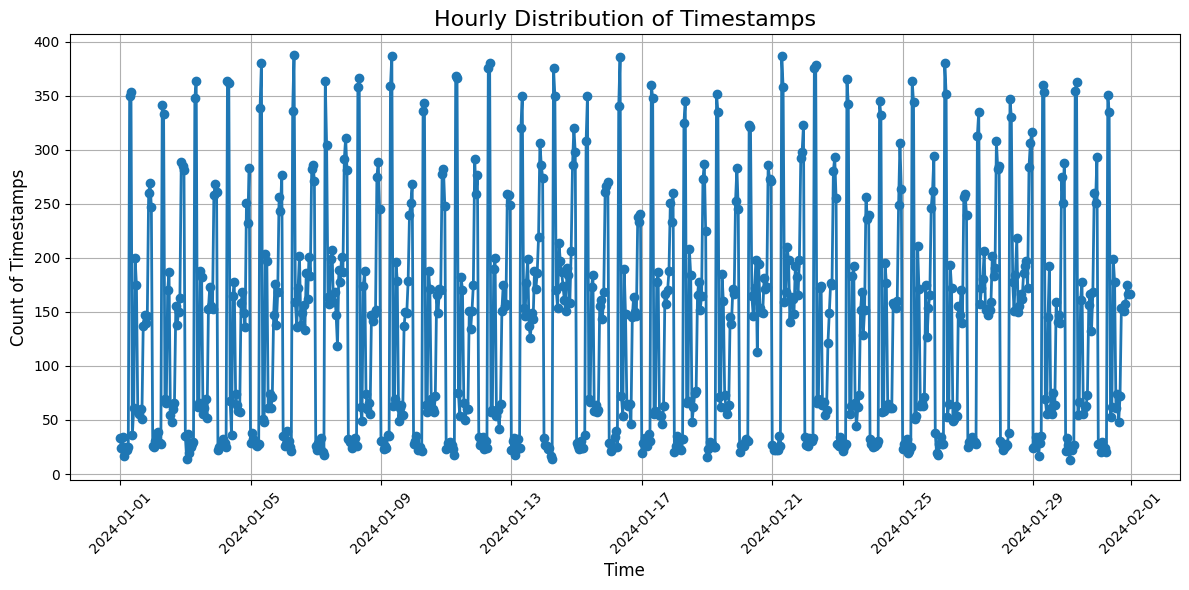

In [7]:
generate.plot_hourly_distribution(df=df)

In [32]:
generate.plotly_hourly_distribution(df=df)

,index,hour,count
0,0,2024-01-01 00:00:00,2
1,1,2024-01-01 01:00:00,2
2,2,2024-01-01 02:00:00,5
3,3,2024-01-01 03:00:00,1
4,4,2024-01-01 04:00:00,5
...,...,...,...
725,725,2024-01-31 19:00:00,16
726,726,2024-01-31 20:00:00,21
727,727,2024-01-31 21:00:00,20
728,728,2024-01-31 22:00:00,15


In [36]:
## Define the target mode and range for lognormal distribution
#target_mode = 6 * 24 * 60 * 60  # 6 days in seconds
#target_range = (5 * 24 * 60 * 60, 7 * 24 * 60 * 60)  # 5 to 7 days in seconds

target_mode = 12 * 60 * 60  # 12 hours in seconds
target_range = (12 * 60 * 60, 2 * 24 * 60 * 60)  # 12 hours to 2 days in seconds


# Find parameters
mu, sigma, probability = find_lognormal_params(target_mode, target_range, tolerance=0.32)
print(f"Mu: {mu}, Sigma: {sigma}, probability: {probability}")


Mu: 10.924497486755536, Sigma: 0.5009009009009009, probability: 0.6800753217432125


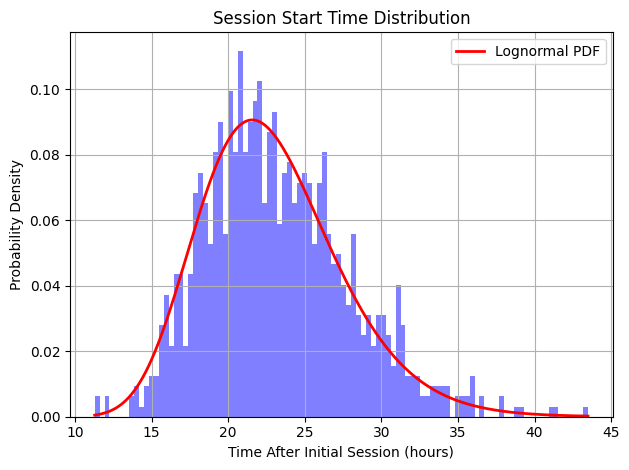

First few session start times:
609   2024-01-01 11:17:24.491940752
698   2024-01-01 11:25:44.658205360
709   2024-01-01 11:58:21.665681494
865   2024-01-01 11:59:07.037247805
236   2024-01-01 13:36:19.268821873
734   2024-01-01 13:37:57.896936141
869   2024-01-01 14:00:57.610033561
24    2024-01-01 14:03:34.932029478
368   2024-01-01 14:07:03.398944989
154   2024-01-01 14:16:57.895587817
dtype: datetime64[ns]


In [54]:
cluster_stats = cluster_attributes()

timestamp='2024-01-01 00:00:00'
mu_g = cluster_stats.get('g').get('session_start_mu')
sigma_g = cluster_stats.get('g').get('session_start_sigma')

plot_session_start_distribution(initial_timestamp=timestamp,
                                mu=mu_g,
                                sigma=sigma_g,
                                num_samples=1000,
                                time_unit='hours'
                                )

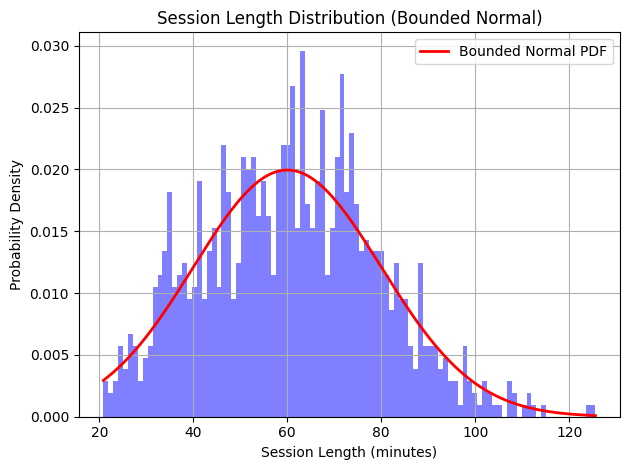

First few session lengths:
335    20.852546
742    21.168025
990    21.497254
541    21.962135
220    22.095397
800    23.041425
676    23.534121
371    23.657772
99     24.189578
976    24.240286
dtype: float64


In [42]:
cluster_stats = cluster_attributes()

mu_length_b = cluster_stats.get('b').get('session_length_mu')
sigma_length_b = cluster_stats.get('b').get('session_length_sigma')

mu_length_g = cluster_stats.get('g').get('session_length_mu')
sigma_length_g = cluster_stats.get('g').get('session_length_sigma')

plot_session_length_distribution(
    mu=mu_length_b,
    sigma=sigma_length_b
)

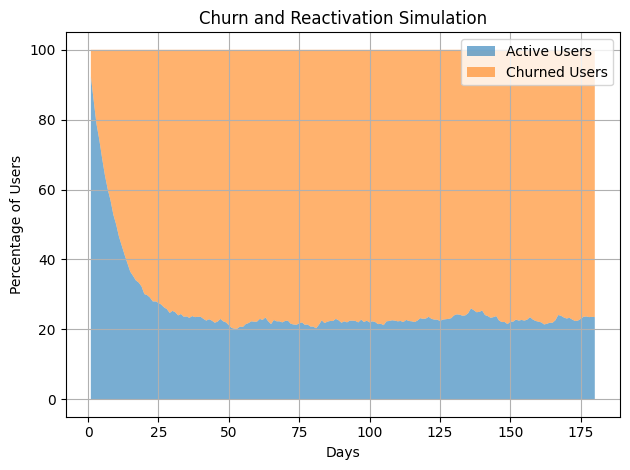

In [69]:
# Simulate the churn and reactivation process
churn_chance = 5  # 5% daily chance of churning
reactivation_chance = 2  # 2% daily chance of reactivation
sessions_per_day = 1.5  # Average 1.5 sessions per day
num_customers = 1000  # Simulate 1000 customers
num_days = 180  # Simulate for 180 days

# Run simulation
results = simulate_churn_reactivation(churn_chance, reactivation_chance, sessions_per_day, num_customers, num_days)

# Visualize results
plot_churn_simulation(results)

In [43]:
cluster_stats = cluster_attributes()

timestamp='2024-01-01 00:00:00'

# Session timestamps Babylon
mu_start_b = cluster_stats.get('b').get('session_start_mu')
sigma_start_b = cluster_stats.get('b').get('session_start_sigma')

start = session_start(
    initial_timestamp=timestamp,
    mu=mu_start_b,
    sigma=sigma_start_b
    )

mu_length_b = cluster_stats.get('b').get('session_length_mu')
sigma_length_b = cluster_stats.get('b').get('session_length_sigma')


if start is not None:
    session_length, end = session_end(
        mean=mu_length_b,
        std_dev=sigma_length_b,
        start_timestamp=start
    )
else:
    end = None

print(f'''
      B session started at {start}
      B session ended at {end}]''')


# Session timestamps
mu_start_g = cluster_stats.get('g').get('session_start_mu')
sigma_start_g = cluster_stats.get('g').get('session_start_sigma')

start = session_start(
    initial_timestamp=timestamp,
    mu=mu_start_g,
    sigma=sigma_start_g
    )

mu_length_g = cluster_stats.get('g').get('session_length_mu')
sigma_length_g = cluster_stats.get('g').get('session_length_sigma')


if start is not None:
    session_length, end = session_end(
        mean=mu_length_g,
        std_dev=sigma_length_g,
        start_timestamp=start
    )
else:
    end = None

print(f'''
      G session started at {start}
      G session ended at {end}]''')




      B session started at 2024-01-07 06:00:42.258604791
      B session ended at 2024-01-07 07:20:14.242921584]

      G session started at 2024-01-02 00:23:57.917267341
      G session ended at 2024-01-02 00:51:11.511244149]


In [18]:
# TODO:
# [x] Create function for checking timestamp and moving it up or down based on nighttime, workday, weekend
#   [x] Revisit for not initial

# [x] Generate initial df for each customer installation time (timeframe start, timeframe length (days)
#   [x] Inside function there is even distribution random, and timestamp mover (for night, weekend, workday)
#   [x] cOutput: Dataframe with id, initial cluster, and first intallation timestamp

# [x] Revisit generating new user clusters - Likelihood instead of straight up deterministic number

# [] Auxiliary functions for visualizing
#   [x] Lognormal distribution
#   [x] Normal distribution
#   [] Session cumulation and churn for cluster
#   [] Purchase revenue cumulation (absolute and per cluster participant)
#   [] Original cluster participant status share over time

# [] Dictionary where for each cluster, there is dictionary containing at least following:
#   [x] Distribution of next session start (lognormal)
#   [x] Length of next session (normal, bounded and scaled)
#   [] Dictionary containing likelihood of changing cluster after session end
#   [] Dictionary of likelihoods of there being a certain type of purchase (Event, cosmetic, general internal currency for advancing game)
#   [] Dictionary of distributions of the purchase taking place (lognormal) for each type - generated from start and since last transaction until end
#       of session, so multiple transactions can take place for keen users
#   [] Distribution of size of each transaction (maybe just an array of sizes and set probabilities)
#   [] Distribution of activities:
#       [] Visit skin store
#       [] Visit other resource sink
#       [] Progress game proper (build resource base)
#       [] Do a match in game proper (test of skill)
#       [] Browse events

# [o] Build skeleton on how to proceed with
#   [o] checking each activity
#   [x] loop through sessions until end of timeframe
#   [o] and log activities
#   [o] and log churned into churn list
#   [o] And pass the churn list to recursive function which will check the reactivation, generate sessions, activities, and churn for reactivated,
#       and recursively pass new churn list to itself if not empty (will be empty if none reactivates, or none reactivated churns again)

# [] Now I have pandas dataframe logging for each user for timeframe fct_user_action:
#   [o] User id
#   [o] Activity Timestamp
#   [o] Activity type (install, transaction (type), activity a to e)
#   [o] Related session id (user-id-dash-running-session-id)
#   [o] Related session start timestamp
#   [o] Related session end timestamp
#   [o] OG cluster
#   [o] Related session started cluster (churned if reactivated)
#   [o] Related session ended cluster (e.g. churned or silently churned)

In [58]:
def main_pseudo():
    
    # Generate dictionary of user clusters
    cluster_shares = {
        'a': 0,
        'b': 10,
        'c': 0,
        'd': 0,
        'e': 0,
        'f': 0,
        'g': None,
    }
    users_dict = generate.initial_clusters(
        cohort_size=1,
        shares=cluster_shares
        )
    

    # Generate installation timestamps for all users
    df = generate.installation_timestamps(users_dict, '2024-01-01', 31)

    ## DEBUG:
    df = df.sort_values(by=['cluster', 'timestamp'], ascending=[True, True])
    display_scrollable(df)
    ## /DEBUG

    ## Start main part of user action generation
    # pseudocode
    # for each user id
#       Add installation to df_fct_user_action
#       start_cluster = og_cluster
#       While session_end < 180 days from start of the timeframe:
#           if first session and 80%:
#               bounding_timestamp = installation_timestamp
#               80% chance: First session on installation
#           elif first session and 20% chance:
#               bounding_timestamp = installation_timestamp
#               session_start(initial_timestamp=installation_timestamp)
#               adjust_timestamps(session_start, start=installation_timestamp) -> pd.Timestamp
#           else:
#               bounding_timestamp = previous_session_end
#               session_start(initial_timestamp=bounding_timestamp)
#               if campaign_start() between bounding timestamp and session start (and some other campaign_start condition)
#                   session start = campaign_start() timestamp
#               adjust_timestamps(session_start, start=bounding_timestamp) -> pd.Timestamp
#           session_length, session_end = session_end(mean=mu_length_user_cluster, std_dev=sigma_length_user_cluster, start_timestamp=start)
#           
#           if session_start > 180 days from start of the timeframe:
#               break
#           Randomize new cluster for session end cluster
#           -> Now I have for this session: user, session_id (generate this, running number), session start,
#               session length, session end, og cluster, session start cluster, session end cluster
#           Start generating actions (think this through later, basically loop each action start time from session start
#               until goes over session end, disregard last)
#           Append activity timestamps, type, transaction size, etc. with all user and session specific attributes to df_fct_user_action
#           user_cluster = end_cluster
#               if user_cluster == f (churned):
#                   Append user with last session end timestamp to df_churned
#                   break
#
#   x = recursive_reactivation(df_churned, date_of_end)
#   for z in x:
#       append to fct_user_action



# def recursive_reactivation(df_churned, date_of_end):
#   df_churned_new = pd.df.empty
#   for each user: Roll date of reactivation (if any: chance of reactivating + timestamp of reactivation)
#       If reactivates AND date of reactivation < date_of_end:
#           Session at the moment of reactivation
#           Basic session stuff
#           yield user action row
#           if session end_cluster = f AND session_end_time < date_of_end
#               Append user with last session end timestamp to df_churned_new
#   if df_churned_new is not empty:
#       yield from recursive_reactivation(df_churned_new, date_of_end)



In [66]:
def main():
    
    # Generate dictionary of user clusters
    cluster_shares = {
        'a': 0,
        'b': 10,
        'c': 0,
        'd': 0,
        'e': 0,
        'f': 0,
        'g': None,
    }
    users_dict = generate.initial_clusters(
        cohort_size=1,
        shares=cluster_shares
        )
    

    # Generate installation timestamps for all users
    df = generate.installation_timestamps(users_dict, '2024-01-01', 31)

    columns = [
        'user_id', 'session_id', 'session_start', 'session_length', 'session_end',
        'original_cluster', 'session_start_cluster', 'session_end_cluster',
        'action_id', 'action_timestamp', 'transaction_size'
    ]
    fct_user_action = pd.DataFrame(columns=columns)
    
    cluster_stats = cluster_attributes()

    for _, user_row in df.iterrows():
        user_id = user_row['customer_id']
        original_cluster = user_row['cluster']
        install_timestamp = user_row['timestamp']

        # Add initial "install" row to fct_user_action
        fct_user_action = pd.concat([fct_user_action, pd.DataFrame([{
            'user_id': user_id,
            'session_id': None,
            'session_start': None,
            'session_length': None,
            'session_end': None,
            'original_cluster': original_cluster,
            'session_start_cluster': None,
            'session_end_cluster': None,
            'action_id': 'install',
            'action_timestamp': install_timestamp,
            'transaction_size': None
        }])], ignore_index=True)

        # Prepare for session generation
        session_start_cluster = original_cluster
        session_end_timestamp = None
        running_session_number = 0

        while session_end_timestamp is None or (session_end_timestamp < install_timestamp + pd.Timedelta(days=180)):
            # Determine session_start_timestamp
            if session_end_timestamp is None:  # First session
                if random.random() < 0.8:  # 80% chance
                    session_start_timestamp = install_timestamp + pd.Timedelta(seconds=30)
                else:  # 20% chance
                    mu = cluster_stats[session_start_cluster]['session_start_mu']
                    sigma = cluster_stats[session_start_cluster]['session_start_sigma']
                    session_start_timestamp = session_start(install_timestamp, mu, sigma)
            else:  # Subsequent sessions
                mu = cluster_stats[session_start_cluster]['session_start_mu']
                sigma = cluster_stats[session_start_cluster]['session_start_sigma']
                session_start_timestamp = session_start(session_end_timestamp, mu, sigma)

            # Break if session_start_timestamp is None
            print(f'DEBUG: {session_start_timestamp}')
            if session_start_timestamp is None:
                break

            # Adjust session_start_timestamp
            session_start_timestamp = generate.adjust_timestamps(session_start_timestamp, install_timestamp if session_end_timestamp is None else session_end_timestamp)

            # Generate session_end
            mu = cluster_stats[session_start_cluster]['session_length_mu']
            sigma = cluster_stats[session_start_cluster]['session_length_sigma']
            session_length, session_end_timestamp = session_end(mu, sigma, session_start_timestamp)

            # Break if session_end_timestamp exceeds 180 days after install
    #        if session_end_timestamp > install_timestamp + pd.Timedelta(days=180):
    #            break

            # Add session row to fct_user_action
            session_id = f"{user_id}-{running_session_number}"
            fct_user_action = pd.concat([fct_user_action, pd.DataFrame([{
                'user_id': user_id,
                'session_id': session_id,
                'session_start': session_start_timestamp,
                'session_length': session_length,
                'session_end': session_end_timestamp,
                'original_cluster': original_cluster,
                'session_start_cluster': session_start_cluster,
                'session_end_cluster': session_start_cluster,  # For now, same as session_start_cluster
                'action_id': 'session_start',
                'action_timestamp': session_start_timestamp,
                'transaction_size': None
            }])], ignore_index=True)

            # Update session_start_cluster for next session
            session_start_cluster = session_start_cluster  # Logic to determine next cluster can be added here
            running_session_number += 1

    display_scrollable(fct_user_action)


In [67]:
main()

C:\Users\PyryHuhtanen\AppData\Local\Temp\ipykernel_29560\3275818471.py:37: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\PyryHuhtanen\AppData\Local\Temp\ipykernel_29560\3275818471.py:89: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



DEBUG: 2024-01-13 19:02:26
DEBUG: 2024-01-14 13:05:00.102337763
DEBUG: 2024-01-15 07:26:19.984848176
DEBUG: 2024-01-16 06:25:29.437761175
DEBUG: 2024-01-17 07:17:26.110073816
DEBUG: 2024-01-17 20:14:01.088061866
DEBUG: 2024-01-18 18:20:49.193752747
DEBUG: 2024-01-19 18:54:24.798031045
DEBUG: 2024-01-20 15:07:43.455627268
DEBUG: 2024-01-21 12:01:40.712621866
DEBUG: 2024-01-22 23:41:05.489736632
DEBUG: 2024-01-23 19:21:06.917294498
DEBUG: 2024-01-24 17:22:35.346932414
DEBUG: 2024-01-25 12:10:35.072222361
DEBUG: 2024-01-26 08:17:37.436242337
DEBUG: 2024-01-27 14:27:45.819062109
DEBUG: 2024-01-28 15:59:41.365070053
DEBUG: 2024-01-29 19:19:23.953554155
DEBUG: 2024-01-30 16:22:01.466454603
DEBUG: 2024-01-31 17:46:31.656853541
DEBUG: 2024-02-01 16:38:45.547523788
DEBUG: 2024-02-02 08:48:12.836221993
DEBUG: 2024-02-03 20:25:13.517373141
DEBUG: 2024-02-04 15:13:47.704234496
DEBUG: 2024-02-06 08:51:55.779032894
DEBUG: 2024-02-07 07:13:29.211105697
DEBUG: 2024-02-08 06:05:18.509795729
DEBUG: 2024

,user_id,session_id,session_start,session_length,session_end,original_cluster,session_start_cluster,session_end_cluster,action_id,action_timestamp,transaction_size
0,0,None,NaT,NaN,NaT,g,None,None,install,2024-01-13 19:01:56.000000000,None
1,0,0-0,2024-01-13 19:02:26.000000000,1799.846929,2024-01-13 19:32:25.846928658,g,g,g,session_start,2024-01-13 19:02:26.000000000,None
2,0,0-1,2024-01-14 13:05:00.102337763,1027.280929,2024-01-14 13:22:07.383266351,g,g,g,session_start,2024-01-14 13:05:00.102337763,None
3,0,0-2,2024-01-15 07:26:19.984848176,1323.794283,2024-01-15 07:48:23.779131312,g,g,g,session_start,2024-01-15 07:26:19.984848176,None
4,0,0-3,2024-01-16 08:25:29.437761175,536.129468,2024-01-16 08:34:25.567228796,g,g,g,session_start,2024-01-16 08:25:29.437761175,None
5,0,0-4,2024-01-17 07:17:26.110073816,791.565545,2024-01-17 07:30:37.675618879,g,g,g,session_start,2024-01-17 07:17:26.110073816,None
6,0,0-5,2024-01-17 20:14:01.088061866,1416.759647,2024-01-17 20:37:37.847708840,g,g,g,session_start,2024-01-17 20:14:01.088061866,None
7,0,0-6,2024-01-18 18:20:49.193752747,1728.000131,2024-01-18 18:49:37.193883432,g,g,g,session_start,2024-01-18 18:20:49.193752747,None
8,0,0-7,2024-01-19 18:54:24.798031045,267.039852,2024-01-19 18:58:51.837882784,g,g,g,session_start,2024-01-19 18:54:24.798031045,None
9,0,0-8,2024-01-20 15:07:43.455627268,1817.583939,2024-01-20 15:38:01.039566088,g,g,g,session_start,2024-01-20 15:07:43.455627268,None


In [23]:
#print(random.choice([1,2,3,4,5,6]))

def recursive():
    die_roll = random.choice([1, 2, 3, 4, 5, 6])
    yield die_roll
    if die_roll != 6:
        time.sleep(1)
        yield from recursive()

x = recursive()

for z in x:
    if z != 6:
        print(f'Rolled {z}, rolling again')
    else:
        print(f'Rolled {z}, no more rolling')

Rolled 4, rolling again
Rolled 1, rolling again
Rolled 6, no more rolling


In [55]:
def recursive_with_argument(numbers):
    die_roll = random.choice([1, 2, 3, 4, 5, 6])
    if die_roll in numbers:
        numbers.remove(die_roll)
    yield die_roll, numbers
    if numbers != []:
        time.sleep(1)
        yield from recursive_with_argument(numbers)

numbers_list = [1, 2, 3, 4, 5, 6]

print(f'Starting with list {numbers_list}')
time.sleep(1)
for roll, list in recursive_with_argument(numbers_list):
    if list != []:
        print(f'Rolled {roll}, list now {list}')
    else:
        print(f'Rolled {roll}, list now empty')

Starting with list [1, 2, 3, 4, 5, 6]
Rolled 4, list now [1, 2, 3, 5, 6]
Rolled 3, list now [1, 2, 5, 6]
Rolled 2, list now [1, 5, 6]
Rolled 4, list now [1, 5, 6]
Rolled 6, list now [1, 5]
Rolled 5, list now [1]
Rolled 5, list now [1]
Rolled 4, list now [1]
Rolled 5, list now [1]
Rolled 6, list now [1]
Rolled 2, list now [1]
Rolled 5, list now [1]
Rolled 6, list now [1]
Rolled 6, list now [1]
Rolled 6, list now [1]
Rolled 3, list now [1]
Rolled 4, list now [1]
Rolled 6, list now [1]
Rolled 5, list now [1]
Rolled 3, list now [1]
Rolled 4, list now [1]
Rolled 1, list now empty
